In [ ]:
#SYNTHETIC DATA FOR CONGESTION METRIC CALCULATION

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Travel_Times - Washington DC.csv")
df.head()

,Origin Movement ID,Origin Display Name,Origin Geometry,Destination Movement ID,Destination Display Name,Destination Geometry,Date Range,Mean Travel Time (Seconds),Range - Lower Bound Travel Time (Seconds),Range - Upper Bound Travel Time (Seconds)
0,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",1,"5400 Arnold Avenue Southwest, Southwest Washin...","[[-77.048009,38.841266],[-77.047969,38.841267]...","07/31/2016 - 08/28/2016, Every day, Daily Average",830,563,1221
1,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",2,"1400 Juniper Street Northwest, Northwest Washi...","[[-77.051623,38.987145],[-77.051769,38.987244]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1660,1313,2097
2,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",3,"4800 Canal Road Northwest, Northwest Washingto...","[[-77.119751,38.93435],[-77.118861,38.935356],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1296,974,1724
3,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",4,"2700 Unicorn Lane Northwest, Northwest Washing...","[[-77.071647,38.971786],[-77.07125,38.972087],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1694,1331,2154
4,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",5,"4500 Q Place Northwest, Northwest Washington, ...","[[-77.100859,38.911209],[-77.099577,38.911988]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1082,776,1507


In [ ]:
#Assumptions for Urban intersection dense area.
distance_km = 1.0  #Average OD distance in central DC
free_flow_speed = 60 #km/hr (urban free-flow speed)

In [ ]:
df["travel_time_sec"] = df["Mean Travel Time (Seconds)"]

In [ ]:
#Compute average speed.
df["average_speed_kmh"] = (distance_km/df["travel_time_sec"])*3600 #Convert it to hours.

In [ ]:
#Compute free_flow travel time in seconds
df["free_flow_time_sec"] = (distance_km/free_flow_speed)*3600

In [ ]:
#Compute delay (observed - free flow) in seconds
df["delay_sec"] = df["travel_time_sec"] - df["free_flow_time_sec"]

In [ ]:
#Computing congestion index
df["congestion_index"] = (free_flow_speed - df["average_speed_kmh"])/free_flow_speed

In [ ]:
#Sanithy check.
df[["Mean Travel Time (Seconds)", "average_speed_kmh","delay_sec","congestion_index"]].head()

,Mean Travel Time (Seconds),average_speed_kmh,delay_sec,congestion_index
0,830,4.337349,770.0,0.927711
1,1660,2.168675,1600.0,0.963855
2,1296,2.777778,1236.0,0.953704
3,1694,2.125148,1634.0,0.964581
4,1082,3.327172,1022.0,0.944547


In [ ]:
df.to_csv("Travel_Times_DC_with_congestion.csv", index=False)


In [ ]:
#SYNTHETIC DATA FOR EMISSION BASED CALCULATIONS

In [ ]:
#IMPORTING LIBRARIES
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/Travel_Times_DC_with_congestion.csv")
df.head()

,Origin Movement ID,Origin Display Name,Origin Geometry,Destination Movement ID,Destination Display Name,Destination Geometry,Date Range,Mean Travel Time (Seconds),Range - Lower Bound Travel Time (Seconds),Range - Upper Bound Travel Time (Seconds),travel_time_sec,average_speed_kmh,free_flow_time_sec,delay_sec,congestion_index
0,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",1,"5400 Arnold Avenue Southwest, Southwest Washin...","[[-77.048009,38.841266],[-77.047969,38.841267]...","07/31/2016 - 08/28/2016, Every day, Daily Average",830,563,1221,830,4.337349,60.0,770.0,0.927711
1,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",2,"1400 Juniper Street Northwest, Northwest Washi...","[[-77.051623,38.987145],[-77.051769,38.987244]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1660,1313,2097,1660,2.168675,60.0,1600.0,0.963855
2,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",3,"4800 Canal Road Northwest, Northwest Washingto...","[[-77.119751,38.93435],[-77.118861,38.935356],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1296,974,1724,1296,2.777778,60.0,1236.0,0.953704
3,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",4,"2700 Unicorn Lane Northwest, Northwest Washing...","[[-77.071647,38.971786],[-77.07125,38.972087],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1694,1331,2154,1694,2.125148,60.0,1634.0,0.964581
4,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",5,"4500 Q Place Northwest, Northwest Washington, ...","[[-77.100859,38.911209],[-77.099577,38.911988]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1082,776,1507,1082,3.327172,60.0,1022.0,0.944547


In [ ]:
#Defining emission model constsnts(Assumptions)
a = 300 #constant term
b = -5 # linear speed term
c = 0.1 #quadratic speed term.

In [ ]:
#Compute CO2 emissions per km.
df["co2_g_per_km"] = a+b*df["average_speed_kmh"]+c*(df["average_speed_kmh"]**2)

In [ ]:
#OD=1.0 as we assumed.
#Emissions per OD trip
OD_distance_km = 1.0
df["co2_g_per_trip"] = df["co2_g_per_km"]*OD_distance_km

In [ ]:
#Sanity check
df[["average_speed_kmh","co2_g_per_km","co2_g_per_trip"]].head()

,average_speed_kmh,co2_g_per_km,co2_g_per_trip
0,4.337349,280.194513,280.194513
1,2.168675,289.626942,289.626942
2,2.777778,286.882716,286.882716
3,2.125148,289.825887,289.825887
4,3.327172,284.471148,284.471148


In [ ]:
df.to_csv("Travel_Times_DC_with_congestion_emissions.csv", index=False)


In [ ]:
#EMISSION-CONGESTION DECOUPLING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/Travel_Times_DC_with_congestion_emissions.csv")
df.head()

,Origin Movement ID,Origin Display Name,Origin Geometry,Destination Movement ID,Destination Display Name,Destination Geometry,Date Range,Mean Travel Time (Seconds),Range - Lower Bound Travel Time (Seconds),Range - Upper Bound Travel Time (Seconds),travel_time_sec,average_speed_kmh,free_flow_time_sec,delay_sec,congestion_index,co2_g_per_km,co2_g_per_trip
0,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",1,"5400 Arnold Avenue Southwest, Southwest Washin...","[[-77.048009,38.841266],[-77.047969,38.841267]...","07/31/2016 - 08/28/2016, Every day, Daily Average",830,563,1221,830,4.337349,60.0,770.0,0.927711,280.194513,280.194513
1,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",2,"1400 Juniper Street Northwest, Northwest Washi...","[[-77.051623,38.987145],[-77.051769,38.987244]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1660,1313,2097,1660,2.168675,60.0,1600.0,0.963855,289.626942,289.626942
2,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",3,"4800 Canal Road Northwest, Northwest Washingto...","[[-77.119751,38.93435],[-77.118861,38.935356],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1296,974,1724,1296,2.777778,60.0,1236.0,0.953704,286.882716,286.882716
3,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",4,"2700 Unicorn Lane Northwest, Northwest Washing...","[[-77.071647,38.971786],[-77.07125,38.972087],...","07/31/2016 - 08/28/2016, Every day, Daily Average",1694,1331,2154,1694,2.125148,60.0,1634.0,0.964581,289.825887,289.825887
4,186,"20001, Northwest Washington, Washington","[[-77.033645,38.897345],[-77.033644,38.898314]...",5,"4500 Q Place Northwest, Northwest Washington, ...","[[-77.100859,38.911209],[-77.099577,38.911988]...","07/31/2016 - 08/28/2016, Every day, Daily Average",1082,776,1507,1082,3.327172,60.0,1022.0,0.944547,284.471148,284.471148


In [ ]:
#Defining the baseline
#Median traffic condition for both congestion and emission
baseline_congestion = df["congestion_index"].median()
baseline_emission = df["co2_g_per_km"].median()

In [ ]:
#Computing percentage changes
#This represents if delta_congestion < 0 --> congestion reduces
#if delta_emission < 0 --> emission reduces
df["delta_congestion"] = (df["congestion_index"]-baseline_congestion)/baseline_congestion
df["delta_emission"] = (df["co2_g_per_km"] - baseline_emission)/baseline_emission

In [ ]:
#Computing decoupling index
#This explains how emission respond to congestion changes
df["decoupling_index"] = df["delta_emission"]/df["delta_congestion"]

In [ ]:
#Handling numerical issues like division-by-zero artifacts and unstable points
df = df.replace([np.inf, -np.inf],np.nan)
df = df.dropna(subset=["decoupling_index"])

In [ ]:
#Classifying decouploing regimes
def classify_decoupling(row):
  if row["delta_congestion"] < 0 and row["delta_emission"] <0:
    return "Coupled"
  elif row["delta_congestion"]<0 and row["delta_emission"] > 0:
    return "Decoupled"
  else:
    return "Other"
df["decoupling_type"] = df.apply(classify_decoupling, axis = 1)

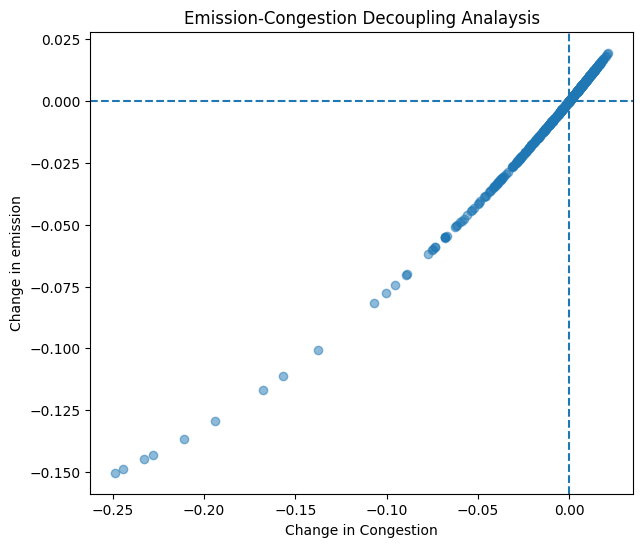

In [ ]:
#Scatter plot
plt.figure(figsize=(7,6))
plt.scatter(df["delta_congestion"], df["delta_emission"], alpha=0.5)

plt.axhline(0, linestyle = "--")
plt.axvline(0, linestyle = "--")

plt.xlabel("Change in Congestion")
plt.ylabel("Change in emission")
plt.title("Emission-Congestion Decoupling Analaysis")

plt.show()
#Bottom-left --> Coupled(Both reduces)
#Bottom-right --> Decoupling (congestion reduces and emission increases)

In [ ]:
#Summary statistics
df["decoupling_type"].value_counts(normalize=True) * 100


,proportion
decoupling_type,
Coupled,50.0
Other,50.0


In [ ]:
#Real world intersection-dense analysis is done.

In [ ]:
#STARTING GRID BASED IMPLEMENTATIONS:
'''What we are simulating:

A 5×5 grid of intersections

OD trips crossing multiple intersections

Delay per intersection

Travel time = cruise time + signal delay

From that:

Speed

Emissions

Decoupling '''


'What we are simulating:\n\nA 5×5 grid of intersections\n\nOD trips crossing multiple intersections\n\nDelay per intersection\n\nTravel time = cruise time + signal delay\n\nFrom that:\n\nSpeed\n\nEmissions\n\nDecoupling '

In [ ]:
#Preparing the environment for grid simulation
import pandas as pd
import numpy as np

In [ ]:
#DEFINING GRID PARAMETERS.
grid_size = 5 #5x5 gris
block_length_km = 0.1 #100 meters per block
speed_limit = 40 #km/hr (urban)

In [ ]:
#DEFINING OD TRIPS.
od_trips = {
    "short":2,
    "medium": 4,
     "long":6
}

In [ ]:
#DEFINE INTERSECTION DELAY MODEL
#SIGNALIZED 4-WAY INTERSECTIONS WITH MODERATE DELAY
min_delay = 20 #seconds per intersection
max_delay = 40

In [ ]:
#Generating Grid OD Dataset
grid_data = []
np.random.seed(42) #reproducibility
for trip_type, intersection in od_trips.items():
  distance_km = intersection * block_length_km
  for i in range(50):
    #Random delay per intersection
    delay_per_intersection = np.random.uniform(min_delay, max_delay)
    total_delay = intersection * delay_per_intersection

    #Cruise time(no intersection)
    cruise_time_Sec = (distance_km/speed_limit)

    #Total travel time
    total_time_sec = cruise_time_Sec+total_delay

    grid_data.append([trip_type,intersection,distance_km,total_delay,total_time_sec])


In [ ]:
#Creating a datframe
df_grid = pd.DataFrame(grid_data,columns = ["trip_type", "num_intersections","distance_km","total_delay_sec","total_travel_time_sec"])
df_grid.head()

,trip_type,num_intersections,distance_km,total_delay_sec,total_travel_time_sec
0,short,2,0.2,54.981605,54.986605
1,short,2,0.2,78.028572,78.033572
2,short,2,0.2,69.279758,69.284758
3,short,2,0.2,63.946339,63.951339
4,short,2,0.2,46.240746,46.245746


In [ ]:
#Compute speed congestion metric using this.
df_grid["average_speed_kmph"] = (df_grid["distance_km"]/df_grid["total_travel_time_sec"])*3600

In [ ]:
#ADD EMISSION MODEL
a = 300
b = -5
c = 0.1
df_grid["co2_g_per_km"] = (a+b*df_grid["average_speed_kmph"]+c*(df_grid["average_speed_kmph"]**2))

In [ ]:
#Sanity check
df_grid.groupby("trip_type")[["average_speed_kmph","co2_g_per_km"]].mean()

,average_speed_kmph,co2_g_per_km
trip_type,,
long,12.672960,253.340891
medium,12.585002,253.642616
short,12.940778,252.683616


In [ ]:
#Saving the grid dataset
df_grid.to_csv("grid_signalized_4way.csv", index=False)


In [ ]:
#GRID DECOUPLING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_grid = pd.read_csv("/content/grid_signalized_4way.csv")
df_grid.head()

,trip_type,num_intersections,distance_km,total_delay_sec,total_travel_time_sec,average_speed_kmph,co2_g_per_km
0,short,2,0.2,54.981605,54.986605,13.094098,251.675050
1,short,2,0.2,78.028572,78.033572,9.226798,262.379390
2,short,2,0.2,69.279758,69.284758,10.391896,258.839670
3,short,2,0.2,63.946339,63.951339,11.258560,256.382717
4,short,2,0.2,46.240746,46.245746,15.569000,246.394377


In [ ]:
#Defining baseline reference state
baseline_speed = df_grid["average_speed_kmph"].median()
baseline_emission = df_grid["co2_g_per_km"].median()

In [ ]:
#Computing relative changes
df_grid["delta_speed"] = (df_grid["average_speed_kmph"] - baseline_speed)/baseline_speed
df_grid["delta_emission"] = (df_grid["co2_g_per_km"] - baseline_emission)/baseline_emission

In [ ]:
#Computing decoupling index
df_grid["decoupling_index"] = (df_grid["delta_emission"]/df_grid["delta_speed"])
#DI < 0 → good decoupling

#DI ≈ 0 → weak coupling

#DI > 0 → bad decoupling

In [ ]:
#Clean numerical issue
df_grid = df_grid.replace([np.inf, -np.inf], np.nan)
df_grid = df_grid.dropna(subset=["decoupling_index"])

In [ ]:
#Classify decoupling regimes
def classify_grid_decoupling(row):
  if row["delta_speed"] > 0 and row["delta_emission"] < 0:
    return "Decoupled (GOOD)"
  elif row["delta_speed"] > 0 and row["delta_emission"] > 0:
    return "DeCoupled (BAD)"
  else:
    return "Coupled"
df_grid["decoupling_type"] = df_grid.apply(classify_grid_decoupling, axis = 1)

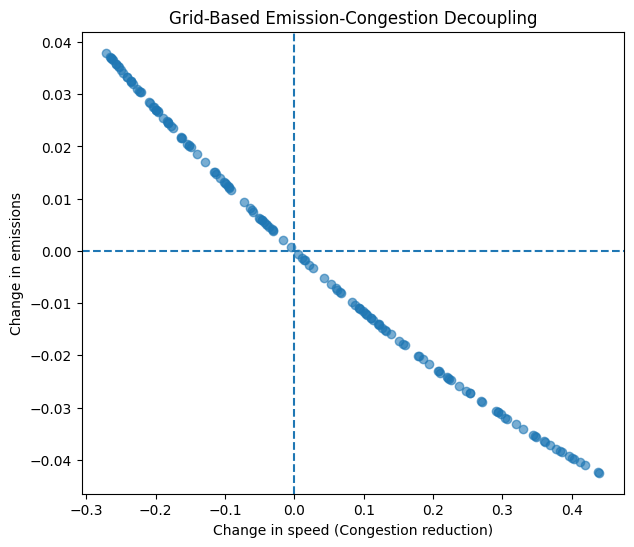

In [ ]:
#Grid decoupling plot
plt.figure(figsize = (7,6))
plt.scatter(df_grid["delta_speed"], df_grid["delta_emission"], alpha = 0.6)
plt.axhline(0,linestyle = "--")
plt.axvline(0,linestyle = "--")
plt.xlabel("Change in speed (Congestion reduction)")
plt.ylabel("Change in emissions")
plt.title("Grid-Based Emission-Congestion Decoupling")
plt.show()

In [ ]:
#Quantifying regimes
df_grid["decoupling_type"].value_counts(normalize=True) * 100


,proportion
decoupling_type,
Decoupled (GOOD),50.0
Coupled,50.0


In [ ]:
#Saving grid decoupling results
df_grid.to_csv("grid_signalized_4way_decoupling.csv", index = False)

In [ ]:
#Define unsignalized delay model
#Delay model for unsignalized/minor intersections.
min_delay_unsignalized = 5
max_delay_unsignalized = 15

In [ ]:
#Generating grid data
grid_data_unsignalized = []
np.random.seed(42)
for trip_type, intersection in od_trips.items():
  distance_km = intersection*block_length_km
  for i in range(50):
    delay_per_intersection = np.random.uniform(min_delay_unsignalized, max_delay_unsignalized)
    total_delay = intersection*delay_per_intersection
    cruise_time_Sec = (distance_km/speed_limit)*3600
    total_time_sec = cruise_time_Sec+total_delay
    grid_data_unsignalized.append([trip_type,intersection,distance_km,total_delay,total_time_sec])

In [ ]:
#Create a dataframe
df_unsignalized = pd.DataFrame(grid_data_unsignalized,columns = ["trip_type", "num_intersections","distance_km","total_delay_sec","total_time_sec"])
df_unsignalized.head()

,trip_type,num_intersections,distance_km,total_delay_sec,total_time_sec
0,short,2,0.2,17.490802,35.490802
1,short,2,0.2,29.014286,47.014286
2,short,2,0.2,24.639879,42.639879
3,short,2,0.2,21.973170,39.973170
4,short,2,0.2,13.120373,31.120373


In [ ]:
#Compute speed for unsignalized intersections
df_unsignalized["average_speed_kmph"] = (df_unsignalized["distance_km"]/df_unsignalized["total_time_sec"])*3600

In [ ]:
#Computing emission
df_unsignalized["co2_g_per_km"] = (a+b*df_unsignalized["average_speed_kmph"]+c*(df_unsignalized["average_speed_kmph"]**2))

In [ ]:
#Decoupling analysis unsignalized
baseline_speed_unsignalized = df_unsignalized["average_speed_kmph"].median()
baseline_emission_unsignalized = df_unsignalized["co2_g_per_km"].median()

df_unsignalized["delta_speed"] = (df_unsignalized["average_speed_kmph"]-baseline_speed_unsignalized)/baseline_speed_unsignalized
df_unsignalized["delta_emission"] = (df_unsignalized["co2_g_per_km"]-baseline_emission_unsignalized)/baseline_emission_unsignalized
df_unsignalized["decoupling_index"] = (df_unsignalized["delta_emission"]/df_unsignalized["delta_speed"])
df_unsignalized = df_unsignalized.replace([np.inf, -np.inf],np.nan)
df_unsignalized = df_unsignalized.dropna(subset=["decoupling_index"])

In [ ]:
df_unsignalized["decoupling_type"] = df_unsignalized.apply(classify_grid_decoupling,axis = 1)

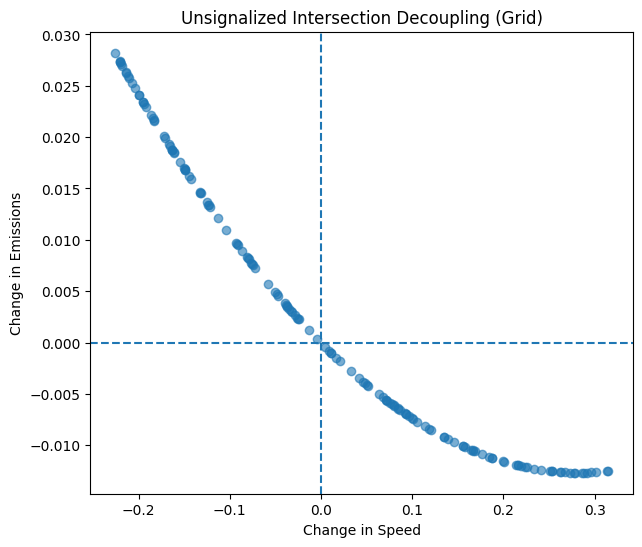

In [ ]:
#Unsignalized decoupling plot
plt.figure(figsize=(7,6))
plt.scatter(
    df_unsignalized["delta_speed"],
    df_unsignalized["delta_emission"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Change in Speed")
plt.ylabel("Change in Emissions")
plt.title("Unsignalized Intersection Decoupling (Grid)")

plt.show()


In [ ]:
#Sve the acquired results
df_unsignalized.to_csv("grid_unsignalized_decoupling.csv", index = False)

In [ ]:
#DEFINING HIGH-VOLUME DELAY INTERSECTIONS
min_delay_hv = 50
max_delay_hv = 90

In [ ]:
#Generate grid data
grid_data_hv = []
np.random.seed(42)
for trip_type, intersection in od_trips.items():
  distance_km = intersection*block_length_km
  for i in range(50):
    delay_per_intersection = np.random.uniform(min_delay_hv,max_delay_hv)
    total_delay = intersection*delay_per_intersection
    cruise_time_Sec = (distance_km/speed_limit)*3600
    total_time_sec = cruise_time_Sec+total_delay
    grid_data_hv.append([trip_type,intersection,distance_km,total_delay,total_time_sec])

In [ ]:
#Create a dataframe
df_hv = pd.DataFrame(grid_data_hv, columns = ["trip_type","num_intersections","distance_km","total_delay_sec","total_time_sec"])
df_hv.head()

,trip_type,num_intersections,distance_km,total_delay_sec,total_time_sec
0,short,2,0.2,129.963210,147.963210
1,short,2,0.2,176.057145,194.057145
2,short,2,0.2,158.559515,176.559515
3,short,2,0.2,147.892679,165.892679
4,short,2,0.2,112.481491,130.481491


In [ ]:
#Compute speed
df_hv["average_speed_kmh"] = (df_hv["distance_km"]/df_hv["total_time_sec"])*3600

In [ ]:
#Compute emissions
df_hv["co2_g_per_km"] = (a+b*df_hv["average_speed_kmh"]+c*(df_hv["average_speed_kmh"]**2))

In [ ]:
#DECOUPLING ANALYSIS FOR HIGH VOLUME
baseline_speed_hv = df_hv["average_speed_kmh"].median()
baseline_emission_hv = df_hv["co2_g_per_km"].median()
df_hv["delta_speed"] = (df_hv["average_speed_kmh"]-baseline_speed_hv)/baseline_speed_hv
df_hv["delta_emission"] = (df_hv["co2_g_per_km"]-baseline_emission_hv)/baseline_emission_hv
df_hv["decoupling_index"] = (df_hv["delta_emission"]/df_hv["delta_speed"])
df_hv = df_hv.replace([np.inf,-np.inf],np.nan)
df_hv = df_hv.dropna(subset=["decoupling_index"])

In [ ]:
#CLASSIFY HIGH VOLUME BEHAVIOUR
df_hv["decoupling_type"] = df_hv.apply(classify_grid_decoupling,axis=1)

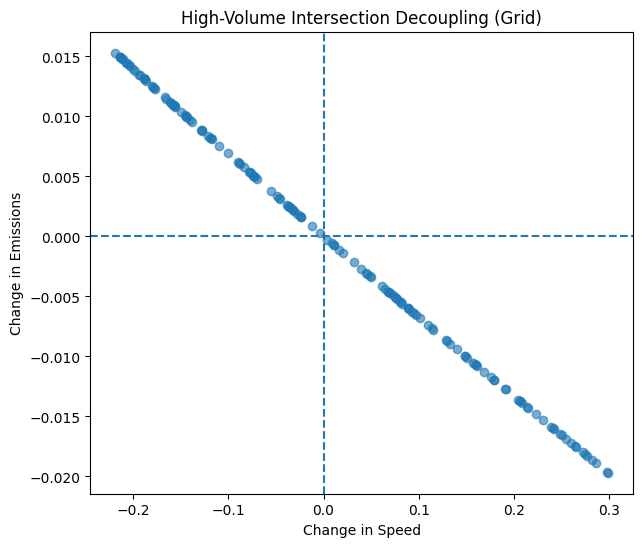

In [ ]:
#High volume decoupling plot
plt.figure(figsize=(7,6))
plt.scatter(
    df_hv["delta_speed"],
    df_hv["delta_emission"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Change in Speed")
plt.ylabel("Change in Emissions")
plt.title("High-Volume Intersection Decoupling (Grid)")

plt.show()


In [ ]:
#SAVING FINAL DATASET
df_hv.to_csv("grid_high_volume_decoupling.csv",index = False)

In [ ]:
#BRINGING ALL RESULTS INTO ONE WORKSPACE FOR COMPARISON
import pandas as pd
#Loading all syntehtic datasets
df_dc = pd.read_csv("Travel_Times_DC_with_congestion_emissions.csv")
df_grid = pd.read_csv("grid_signalized_4way_decoupling.csv")
df_unsig = pd.read_csv("grid_unsignalized_decoupling.csv")
df_hv = pd.read_csv("grid_high_volume_decoupling.csv")

In [ ]:
#STANDARDIZE COLUMNS
def extract_metrics(df, label):
  return pd.DataFrame({"case": label, "average_speed":df['average_speed_kmh'],"co2":df["co2_g_per_km"],"decoupling_type":df["decoupling_type"]})

In [ ]:
# Rename average_speed_kmph to average_speed_kmh for consistency in df_grid and df_unsig
df_grid = df_grid.rename(columns={'average_speed_kmph': 'average_speed_kmh'})
df_unsig = df_unsig.rename(columns={'average_speed_kmph': 'average_speed_kmh'})

df_compare = pd.concat([
    extract_metrics(df, "Washington DC (Real)"),
    extract_metrics(df_grid, "Grid Signalized"),
    extract_metrics(df_unsig, "Grid Unsignalized"),
    extract_metrics(df_hv, "Grid High Volume")
])

In [ ]:
#SUMMARY TABLE
summary = df_compare.groupby("case").agg({"average_speed":"mean","co2":"mean"}).round(2)
summary

,average_speed,co2
case,,
Grid High Volume,4.73,278.64
Grid Signalized,12.73,253.22
Grid Unsignalized,19.71,241.27
Washington DC (Real),3.26,285.13


In [ ]:
# DECOUPLING DISTRIBUTION
decoupling_stats = (
    df_compare
    .groupby(["case", "decoupling_type"])
    .size()
    .unstack(fill_value=0)
)

decoupling_stats


decoupling_type,Coupled,Decoupled (GOOD),Other
case,,,
Grid High Volume,75,75,0
Grid Signalized,75,75,0
Grid Unsignalized,75,75,0
Washington DC (Real),275,0,275


In [ ]:
#CONVERT DECOUPLING DISTRIBUTION TO PERCENTAGES
decoupling_percent = decoupling_stats.div(
    decoupling_stats.sum(axis=1), axis=0
) * 100

decoupling_percent.round(1)


decoupling_type,Coupled,Decoupled (GOOD),Other
case,,,
Grid High Volume,50.0,50.0,0.0
Grid Signalized,50.0,50.0,0.0
Grid Unsignalized,50.0,50.0,0.0
Washington DC (Real),50.0,0.0,50.0


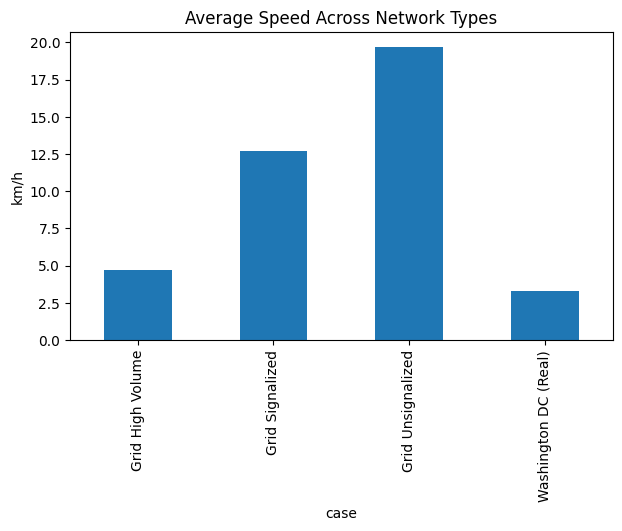

In [ ]:
#COMPARISON PLOT
import matplotlib.pyplot as plt

summary["average_speed"].plot(
    kind="bar",
    title="Average Speed Across Network Types",
    ylabel="km/h",
    figsize=(7,4)
)
plt.show()


In [ ]:
#ML DATASETS TO TRAIN XGBOOST.

In [ ]:
import pandas as pd

In [ ]:
# Load datasets
df_dc = pd.read_csv("Travel_Times_DC_with_congestion_emissions.csv")
df_grid = pd.read_csv("grid_signalized_4way_decoupling.csv")
df_unsignalized = pd.read_csv("grid_unsignalized_decoupling.csv")
df_hv = pd.read_csv("grid_high_volume_decoupling.csv")


In [ ]:
#ADD IDENTIFIERS
df_dc["network_type"] = "Real_DC"
df_grid["network_type"] = "Grid_Signalized"
df_unsignalized["network_type"] = "Grid_Unsignalized"
df_hv["network_type"] = "Grid_HighVolume"


In [ ]:
#ADDING INTERSECTION TYPE
df_dc["intersection_type"] = "Urban_Mixed"
df_grid["intersection_type"] = "Signalized"
df_unsignalized["intersection_type"] = "Unsignalized"
df_hv["intersection_type"] = "HighVolume"


In [ ]:
#STADARDIZE REQUIRED COLUMNS
selected_columns = [
    "average_speed_kmh",
    "congestion_index",
    "total_delay_sec",
    "num_intersections",
    "distance_km",
    "intersection_type",
    "network_type",
    "decoupling_type"
]


In [ ]:
def select_available_columns(df, cols):
    return df[[c for c in cols if c in df.columns]]


In [ ]:
df_dc = select_available_columns(df_dc, selected_columns)
df_grid = select_available_columns(df_grid, selected_columns)
df_unsignalized = select_available_columns(df_unsig, selected_columns)
df_hv = select_available_columns(df_hv, selected_columns)


In [ ]:
#COMBINE INTO ONE ML DATASET
df_ml = pd.concat([df_dc, df_grid, df_unsignalized, df_hv], ignore_index=True)
df_ml.head()


,average_speed_kmh,congestion_index,intersection_type,network_type,total_delay_sec,num_intersections,distance_km,decoupling_type
0,4.337349,0.927711,Urban_Mixed,Real_DC,NaN,NaN,NaN,NaN
1,2.168675,0.963855,Urban_Mixed,Real_DC,NaN,NaN,NaN,NaN
2,2.777778,0.953704,Urban_Mixed,Real_DC,NaN,NaN,NaN,NaN
3,2.125148,0.964581,Urban_Mixed,Real_DC,NaN,NaN,NaN,NaN
4,3.327172,0.944547,Urban_Mixed,Real_DC,NaN,NaN,NaN,NaN


In [ ]:
#CREATE ML LABEL
df_ml["decoupled_label"] = df_ml["decoupling_type"].apply(
    lambda x: 1 if pd.notna(x) and "Decoupled" in x else 0
)

In [ ]:
#HANDLE CATEGORICAL VALUES
df_ml_encoded = pd.get_dummies(
    df_ml,
    columns=["intersection_type", "network_type"],
    drop_first=True
)


In [ ]:
#FINAL SANITY CHECK
df_ml_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   average_speed_kmh              850 non-null    float64
 1   congestion_index               550 non-null    float64
 2   total_delay_sec                450 non-null    float64
 3   num_intersections              450 non-null    float64
 4   distance_km                    450 non-null    float64
 5   decoupling_type                450 non-null    object 
 6   decoupled_label                1000 non-null   int64  
 7   intersection_type_Signalized   1000 non-null   bool   
 8   intersection_type_Urban_Mixed  1000 non-null   bool   
 9   network_type_Grid_Signalized   1000 non-null   bool   
 10  network_type_Real_DC           1000 non-null   bool   
dtypes: bool(4), float64(5), int64(1), object(1)
memory usage: 58.7+ KB


In [ ]:
#MISSING VALUES
df_ml_encoded = df_ml_encoded.dropna()


In [ ]:
#SAVE ML DATASET
df_ml_encoded.to_csv("ml_dataset_xgboost.csv", index=False)


In [ ]:
df_ml_encoded.head()


,average_speed_kmh,congestion_index,total_delay_sec,num_intersections,distance_km,decoupling_type,decoupled_label,intersection_type_Signalized,intersection_type_Urban_Mixed,network_type_Grid_Signalized,network_type_Real_DC


In [ ]:
import pandas as pd
df_ml_encoded = pd.get_dummies(
    df_ml,
    columns=["intersection_type", "network_type"],
    drop_first=True
)


In [ ]:
df_ml_encoded.isnull().sum()


,0
average_speed_kmh,150
congestion_index,450
total_delay_sec,550
num_intersections,550
distance_km,550
decoupling_type,550
decoupled_label,0
intersection_type_Signalized,0
intersection_type_Urban_Mixed,0
network_type_Grid_Signalized,0


In [ ]:
df_ml_encoded = df_ml_encoded.fillna(0)


In [ ]:
df_ml_encoded.shape


(1000, 11)

In [ ]:
df_ml_encoded.head()
df_ml_encoded.sample(5)


,average_speed_kmh,congestion_index,total_delay_sec,num_intersections,distance_km,decoupling_type,decoupled_label,intersection_type_Signalized,intersection_type_Urban_Mixed,network_type_Grid_Signalized,network_type_Real_DC
735,16.301414,0.000000,26.167947,2.0,0.2,Coupled,0,False,False,False,False
168,3.560831,0.940653,0.000000,0.0,0.0,0,0,False,True,False,True
686,0.000000,0.000000,182.254875,6.0,0.6,Coupled,0,True,False,True,False
885,3.941495,0.000000,164.671788,2.0,0.2,Coupled,0,False,False,False,False
187,3.217158,0.946381,0.000000,0.0,0.0,0,0,False,True,False,True


In [ ]:
df_ml_encoded.to_csv("ml_dataset_xgboost.csv", index=False)


In [ ]:
df_ml_encoded.shape


(1000, 11)

In [ ]:
df_ml_encoded.head()
df_ml_encoded.sample(5)


,average_speed_kmh,congestion_index,total_delay_sec,num_intersections,distance_km,decoupling_type,decoupled_label,intersection_type_Signalized,intersection_type_Urban_Mixed,network_type_Grid_Signalized,network_type_Real_DC
330,2.917342,0.951378,0.00000,0.0,0.0,0,0,False,True,False,True
233,3.585657,0.940239,0.00000,0.0,0.0,0,0,False,True,False,True
478,1.902748,0.968288,0.00000,0.0,0.0,0,0,False,True,False,True
519,3.373946,0.943768,0.00000,0.0,0.0,0,0,False,True,False,True
846,17.914331,0.000000,66.57386,6.0,0.6,Coupled,0,False,False,False,False


In [ ]:
# Features = everything except labels
X = df_ml_encoded.drop(columns=["decoupling_type", "decoupled_label"])

# Target = what we want to predict
y = df_ml_encoded["decoupled_label"]

print(X.shape, y.shape)


(1000, 9) (1000,)


In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)


In [ ]:
#EVALUATING PERFORMANCE
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       155
           1       1.00      0.98      0.99        45

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [ ]:
confusion_matrix(y_test, y_pred)


array([[155,   0],
       [  1,  44]])

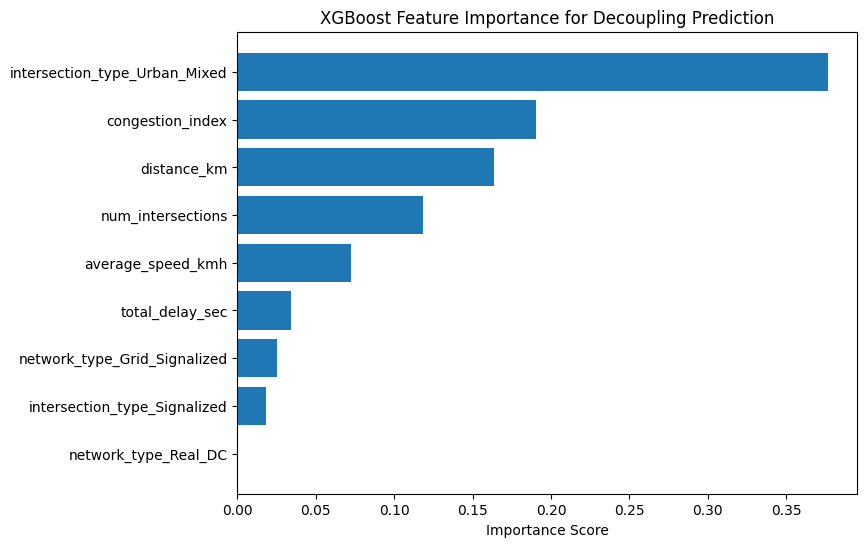

In [ ]:
#FEATURE IMPORTANCE FOR DECOUPLING
import matplotlib.pyplot as plt
import numpy as np

importance = xgb_model.feature_importances_
feature_names = X.columns

sorted_idx = np.argsort(importance)

plt.figure(figsize=(8,6))
plt.barh(feature_names[sorted_idx], importance[sorted_idx])
plt.title("XGBoost Feature Importance for Decoupling Prediction")
plt.xlabel("Importance Score")
plt.show()


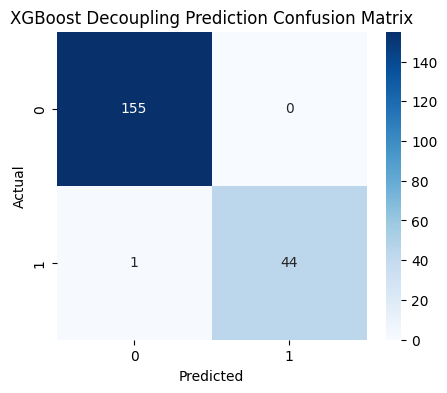

In [ ]:
#VISUALIZATION MODEL
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Decoupling Prediction Confusion Matrix")
plt.show()


In [ ]:
import joblib
joblib.dump(xgb_model, "xgboost_decoupling_model.pkl")


['xgboost_decoupling_model.pkl']

In [ ]:
#RESULT TABLE
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)


Model Accuracy: 0.995


In [ ]:
print(X.columns)


Index(['average_speed_kmh', 'congestion_index', 'total_delay_sec',
       'num_intersections', 'distance_km', 'intersection_type_Signalized',
       'intersection_type_Urban_Mixed', 'network_type_Grid_Signalized',
       'network_type_Real_DC'],
      dtype='object')


In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df.head(10)


,feature,importance
6,intersection_type_Urban_Mixed,0.376498
1,congestion_index,0.190178
4,distance_km,0.163844
3,num_intersections,0.118477
0,average_speed_kmh,0.072504
2,total_delay_sec,0.034437
7,network_type_Grid_Signalized,0.025598
5,intersection_type_Signalized,0.018463
8,network_type_Real_DC,0.000000


In [ ]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

st.title("Emission–Congestion Decoupling Analysis Dashboard")

st.write("This dashboard demonstrates the relationship between traffic congestion and emissions using machine learning.")

# Generate a sample dataset (replace with your dataset if needed)
np.random.seed(42)

data = pd.DataFrame({
    "average_speed_kmh": np.random.uniform(5, 60, 300),
    "congestion_index": np.random.uniform(0.5, 2.5, 300),
    "total_delay_sec": np.random.uniform(10, 300, 300),
    "num_intersections": np.random.randint(1, 10, 300),
    "distance_km": np.random.uniform(0.5, 10, 300)
})

# Emission model
def emission_model(speed):
    a = 0.02
    b = -1.5
    c = 300
    return a*(speed**2) + b*speed + c

data["co2"] = data["average_speed_kmh"].apply(emission_model)

# Create decoupling label
data["decoupled"] = np.where(data["co2"] < data["co2"].mean(), 1, 0)

st.subheader("Dataset Preview")
st.dataframe(data.head())

# Plot relationship
st.subheader("Emission vs Congestion Visualization")

fig, ax = plt.subplots()
ax.scatter(data["congestion_index"], data["co2"])
ax.set_xlabel("Congestion Index")
ax.set_ylabel("Estimated Emission")
st.pyplot(fig)

# Machine Learning Model
X = data[["average_speed_kmh","congestion_index","total_delay_sec","num_intersections","distance_km"]]
y = data["decoupled"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = XGBClassifier()
model.fit(X_train,y_train)

st.subheader("Predict Decoupling")

speed = st.slider("Average Speed",5,80,30)
congestion = st.slider("Congestion Index",0.5,3.0,1.2)
delay = st.slider("Total Delay",0,500,100)
intersections = st.slider("Number of Intersections",1,15,5)
distance = st.slider("Distance (km)",1,20,5)

if st.button("Predict"):

    input_data = np.array([[speed, congestion, delay, intersections, distance]])

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.success("Decoupled: Emission may decrease with congestion change")
    else:
        st.warning("Coupled: Emission follows congestion pattern")

# Feature importance
st.subheader("Feature Importance")

importance = model.feature_importances_

features = X.columns

fig2, ax2 = plt.subplots()
ax2.barh(features, importance)
st.pyplot(fig2)

Overwriting app.py


In [ ]:
!pip install streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
!streamlit run app.py &>/dev/null &